# 2.1 Projections and the Normal Equations

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter II — Orthogonality and Least Squares",
    number="2.1",
    title="Projections and the Normal Equations",
    blurb="When Ax = b has no solution — which is almost always — the useful "
    "question is which x comes closest. The answer is a perpendicular dropped "
    "onto a subspace, and it is the most-used computation in applied mathematics.",
    difficulty="intermediate",
    estimate="75–105 min",
)

<ECP header: 2564 chars of HTML>

## Notebook overview

Chapter I asked what a matrix can reach. This chapter asks what to do when the
thing you want is out of reach, which is the normal situation.

[§1.4](../01-matrices/four-subspaces.ipynb) established that
$A\mathbf{x} = \mathbf{b}$ has a solution exactly when $\mathbf{b}$ lies in the
column space. Real data essentially never does: measure four points that should
lie on a line and they will not, because measurements carry noise and models
are approximations. The system is inconsistent, and asking for an exact
solution is asking the wrong question.

The right question is: which $\mathbf{x}$ makes $A\mathbf{x}$ *closest* to
$\mathbf{b}$? And the answer is entirely geometric. The reachable vectors form
the column space, a subspace; the closest point of a subspace to a given point
is the foot of the perpendicular from it; so the answer is
$\mathbf{p} = P\mathbf{b}$, where $P$ is the orthogonal projector onto $C(A)$.
Everything else in this notebook — the normal equations, the formula
$P = A(A^{\top}A)^{-1}A^{\top}$, the fact that the residual is orthogonal to
every column — is that one sentence written out.

The picture is the one [§1.4](../01-matrices/four-subspaces.ipynb) drew in
$\mathbb{R}^3$: an amber plane, a perpendicular line, and $\mathbf{b}$ split
between them. Here we compute with it. And the residual is not an
embarrassment: it is exactly the component of the data in
$N(A^{\top})$, the part no choice of parameters could ever explain, and its
size is the honest measure of how well the model fits.

One warning to carry forward. The formula $P = A(A^{\top}A)^{-1}A^{\top}$ and
the normal equations $A^{\top}A\hat{\mathbf{x}} = A^{\top}\mathbf{b}$ are
correct, and they are *not* how a numerical library solves least squares.
Forming $A^{\top}A$ squares the condition number, which
[§2.3](least-squares-four-ways.ipynb) measures and
[§2.2](gram-schmidt-qr.ipynb) repairs. This notebook establishes the geometry;
those two fix the arithmetic.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Strang {cite}`strang2023` Chapter 4 is the source of this
> notebook's framing; Boyd and Vandenberghe {cite}`boyd2018` Chapters 12–13
> give the applied version, with far more examples than fit here.

## Theory in brief

### Onto a line, then onto a subspace

[§0.3](../00-machine/vectors-norms-inner-products.ipynb) projected
$\mathbf{b}$ onto a single direction $\mathbf{a}$:

```{math}
:label: eq-proj-line
\mathbf{p} = \frac{\mathbf{a}^{\top}\mathbf{b}}{\mathbf{a}^{\top}\mathbf{a}}\,\mathbf{a}
= \underbrace{\frac{\mathbf{a}\mathbf{a}^{\top}}{\mathbf{a}^{\top}\mathbf{a}}}_{P}\,\mathbf{b} .
```

Written that second way it is a **matrix** times $\mathbf{b}$, and that matrix
is the projector onto the line. Replacing the single column $\mathbf{a}$ by a
full matrix $A$ and repeating the derivation gives the general case.

We want $\mathbf{p} = A\hat{\mathbf{x}}$ in the column space with
$\mathbf{e} = \mathbf{b} - A\hat{\mathbf{x}}$ perpendicular to that space —
that is, perpendicular to every column of $A$. Perpendicular to every column
means $A^{\top}\mathbf{e} = \mathbf{0}$, so

```{math}
:label: eq-proj-normal
A^{\top}\big(\mathbf{b} - A\hat{\mathbf{x}}\big) = \mathbf{0}
\qquad\Longleftrightarrow\qquad
A^{\top}\!A\,\hat{\mathbf{x}} = A^{\top}\mathbf{b} ,
```

the **normal equations**. When $A$ has independent columns, $A^{\top}A$ is
invertible and

```{math}
:label: eq-proj-projector
\hat{\mathbf{x}} = (A^{\top}\!A)^{-1}A^{\top}\mathbf{b},
\qquad
\mathbf{p} = A\hat{\mathbf{x}} = \underbrace{A(A^{\top}\!A)^{-1}A^{\top}}_{P}\,\mathbf{b}.
```

The name "normal" is about the perpendicular, not about normalisation or the
normal distribution.

### What makes $P$ a projector

Two properties characterise an orthogonal projector completely:

```{math}
:label: eq-proj-properties
P^2 = P \quad\text{(idempotent)}, \qquad P^{\top} = P \quad\text{(symmetric)} .
```

Idempotence says projecting an already-projected vector changes nothing —
obvious geometrically, and a real constraint algebraically. Symmetry is what
makes the projection *orthogonal* rather than oblique. Two consequences used
throughout:

- $\operatorname{trace} P = \operatorname{rank} A$, since a projector's
  eigenvalues are all 0 or 1 and the number of 1s is the dimension of the space
  projected onto;
- $I - P$ is also a projector, onto the orthogonal complement — which by
  [§1.4](../01-matrices/four-subspaces.ipynb) is $N(A^{\top})$.

### Least squares, and why "least squares"

Minimising $\|\mathbf{b} - A\mathbf{x}\|_2^2$ over $\mathbf{x}$ and setting the
gradient to zero returns {eq}`eq-proj-normal` exactly. So the geometric answer
and the calculus answer agree, and the quantity being minimised is a sum of
squared residuals — which is where the name comes from. Because
$\mathbf{p} \perp \mathbf{e}$, Pythagoras applies:

```{math}
:label: eq-proj-pythagoras
\|\mathbf{b}\|^2 = \|\mathbf{p}\|^2 + \|\mathbf{e}\|^2 ,
```

so $\|\mathbf{e}\|$ measures exactly how much of the data the model failed to
capture.

---
## Setup

Data only: the worked vectors and matrices. The projector formula — this
notebook's central object — is built in Exercise 2, where it is the lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random vector below comes from this seed

np.set_printoptions(precision=6, suppress=True, linewidth=110)

# The worked data of Exercises 2, 3 and 5: four measurements at integer
# times, chosen
# so the least-squares line comes out with exactly integer coefficients and an
# exactly integer residual, so every check can be made without a tolerance.
T_DATA = np.array([0.0, 1.0, 2.0, 3.0])
B_DATA = np.array([2.0, 1.0, 6.0, 7.0])

## Exercise 1: The projector onto a line is a matrix

{eq}`eq-proj-line` was written in [§0.3](../00-machine/vectors-norms-inner-products.ipynb)
as a formula producing a vector. Regrouping it as
$\big(\mathbf{a}\mathbf{a}^{\top}/\mathbf{a}^{\top}\mathbf{a}\big)\mathbf{b}$
turns it into a **matrix** acting on $\mathbf{b}$, and that shift is what makes
the generalisation to subspaces possible: a projector is an object in its own
right, not a recipe applied to one vector at a time.

The matrix $\mathbf{a}\mathbf{a}^{\top}$ is an outer product, so by
[§1.1](../01-matrices/four-ways-to-multiply.ipynb) it has rank exactly 1 —
and dividing by the scalar $\mathbf{a}^{\top}\mathbf{a}$ does not change that.
So the projector onto a line has rank 1, and its trace must therefore be 1.

Use the specific direction $\mathbf{a} = (2, 1)^{\top}$, for which
$\mathbf{a}^{\top}\mathbf{a} = 5$ and

$$
P = \frac{1}{5}\begin{bmatrix} 4 & 2\\ 2 & 1\end{bmatrix}.
$$

**Part a)** Build $P$ two ways for $\mathbf{a} = (2,1)^{\top}$: as
`np.outer(a, a) / (a @ a)`, and by spelling out the general formula
{eq}`eq-proj-projector` on the column matrix `A1 = a_dir.reshape(-1, 1)` —
`A1 @ np.linalg.solve(A1.T @ A1, A1.T)`. Confirm the two agree to
$10^{-14}$ and both equal the stated $\tfrac15\begin{psmallmatrix}4&2\\2&1\end{psmallmatrix}$.

**Part b)** Confirm the defining properties {eq}`eq-proj-properties`:
$P^2 = P$ and $P^{\top} = P$, each to $10^{-14}$. Then confirm
$\operatorname{trace} P = 1$ and $\operatorname{rank} P = 1$ using
`np.trace` and `np.linalg.matrix_rank`.

**Part c)** Confirm the projector reproduces
[§0.3](../00-machine/vectors-norms-inner-products.ipynb)'s answer: for
$\mathbf{b} = (3,4)^{\top}$, check that $P\mathbf{b}$ equals
$\big((\mathbf{a}^{\top}\mathbf{b})/(\mathbf{a}^{\top}\mathbf{a})\big)\mathbf{a}$
exactly, and that the residual $\mathbf{b} - P\mathbf{b}$ satisfies
$\mathbf{a}^{\top}(\mathbf{b} - P\mathbf{b}) = 0$ to $10^{-15}$.

In [3]:
# (solution hidden on the public site)


P from the outer product:
 [[0.8 0.4]
 [0.4 0.2]]

agrees with the general formula: 0.000e+00
agrees with the stated form: 0.000e+00

P^2 - P        : 1.110e-16
P^T - P        : 0.000e+00
trace P        : 1.0000000000   (= rank of the line)
rank P         : 1

P b            : [4. 2.]
formula of Eq.1: [4. 2.]
residual       : [-1.  2.]   a . residual = 0.000e+00


### Validation 1

The two constructions of $P$ share no code — one is an outer product, one goes
through $(A^{\top}A)^{-1}$ — so their agreement is real evidence rather than a
restatement. The rank and trace checks confirm the object is what its geometry
requires.

In [4]:
validate.close(P_outer, P_helper,
               "the outer-product and (A^T A)^-1 constructions of P agree",
               rtol=0.0, atol=1e-14)
validate.close(P_outer, P_stated,
               "and both equal (1/5)[[4, 2], [2, 1]]", rtol=0.0, atol=1e-14)
validate.close(P_outer @ P_outer, P_outer,
               "P is idempotent: P^2 = P (Eq. 4)", rtol=0.0, atol=1e-14)
validate.close(P_outer.T, P_outer,
               "and symmetric, which is what makes the projection orthogonal",
               rtol=0.0, atol=1e-14)
validate.close(np.trace(P_outer), 1.0,
               "trace P = 1 = the dimension of the line it projects onto",
               rtol=0.0, atol=1e-14)
validate.close(p_matrix, p_formula,
               "P b reproduces the projection formula of section 0.3",
               rtol=0.0, atol=1e-14)
validate.close(a_dir @ resid, 0.0,
               "and the residual is orthogonal to the direction",
               rtol=0.0, atol=1e-15)

✓  the outer-product and (A^T A)^-1 constructions of P agree   [max|Δ| = 0 (rtol=0, atol=1e-14)]
✓  and both equal (1/5)[[4, 2], [2, 1]]   [max|Δ| = 0 (rtol=0, atol=1e-14)]
✓  P is idempotent: P^2 = P (Eq. 4)   [max|Δ| = 1.11022e-16 (rtol=0, atol=1e-14)]
✓  and symmetric, which is what makes the projection orthogonal   [max|Δ| = 0 (rtol=0, atol=1e-14)]
✓  trace P = 1 = the dimension of the line it projects onto   [got 1 vs expected 1 (rtol=0, atol=1e-14)]
✓  P b reproduces the projection formula of section 0.3   [max|Δ| = 0 (rtol=0, atol=1e-14)]
✓  and the residual is orthogonal to the direction   [got 0 vs expected 0 (rtol=0, atol=1e-15)]


True

## Exercise 2: Onto a subspace, and the four facts that follow

Replacing the single column of Exercise 1 by a matrix gives
{eq}`eq-proj-projector`, and the properties generalise exactly.

One subtlety is worth stating because it is the whole reason projectors are the
right object. $P$ depends only on the **column space** of $A$, not on $A$
itself. Replace the columns by any other basis of the same space — scale them,
reorder them, take combinations — and $P$ is unchanged. That is why
[§1.4](../01-matrices/four-subspaces.ipynb) compared subspaces through their
projectors, and it is what makes $P$ a property of the geometry rather than of
the parametrisation.

Use the explicit $4\times2$ matrix

```{math}
:label: eq-proj-design
A = \begin{bmatrix} 1 & 0\\ 1 & 1\\ 1 & 2\\ 1 & 3 \end{bmatrix},
```

whose columns span a two-dimensional subspace of $\mathbb{R}^4$. It is the
**design matrix** of the line fit in Exercise 3: its first column is the
constant term, its second the times $t = 0,1,2,3$.

**Part a)** Write `projector_onto(A)` — {eq}`eq-proj-projector`, computed by
SOLVING with $A^{\top}A$ rather than inverting it. Build $P$ for
{eq}`eq-proj-design` with it, and

**Write this one yourself** — the implementation is the lesson.

confirm $P^2 = P$ and $P^{\top} = P$ to $10^{-13}$, and that
$\operatorname{trace} P = 2 = \operatorname{rank} A$ to $10^{-12}$.

**Part b)** Confirm $P$ acts as the identity on the column space and
annihilates its complement: check $PA = A$ to $10^{-13}$ (every column of $A$
is already in $C(A)$, so projecting changes nothing), and that for the left
null space basis $Y$ obtained as the last **two** columns of
`np.linalg.svd(A)[0]` (the $4\times2$ design has a two-dimensional
$N(A^{\top})$), $PY = 0$ to $10^{-13}$.

**Part c)** Confirm $P$ depends only on the subspace, not on the basis. Form
$A' = A M$ for 50 random invertible $2\times2$ matrices $M$ drawn from
`rng.standard_normal((2, 2))` (rejecting any with $|\det| < 0.1$), build the
projector of each, and confirm every one equals $P$ to $10^{-11}$.

In [5]:
# (solution hidden on the public site)


A (design matrix of Eq. 6):
 [[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]]

P = A (A^T A)^-1 A^T:
 [[ 0.7  0.4  0.1 -0.2]
 [ 0.4  0.3  0.2  0.1]
 [ 0.1  0.2  0.3  0.4]
 [-0.2  0.1  0.4  0.7]]

P^2 - P                 : 2.220e-16
P^T - P                 : 5.551e-17
trace P                 : 2.0000000000   rank A = 2
|P A - A|               : 5.551e-16
|P y| for y in N(A^T)   : 1.290e-16

P is unchanged under 50 changes of basis: max gap 3.905e-13


### Validation 2

The basis-independence check is the important one: it establishes that $P$ is
an invariant of the subspace, which is what licenses using projectors to
compare subspaces at all. The annihilation check uses the left null space from
[§1.4](../01-matrices/four-subspaces.ipynb), a route the projector's
construction never touched.

In [6]:
validate.close(P_sub @ P_sub, P_sub, "P^2 = P for the subspace projector",
               rtol=0.0, atol=1e-13)
validate.close(P_sub.T, P_sub, "and P^T = P", rtol=0.0, atol=1e-13)
validate.close(np.trace(P_sub), 2.0,
               "trace P = 2 = rank A (Eq. 4's consequence)", rtol=0.0, atol=1e-12)
validate.close(P_sub @ A_design, A_design,
               "P acts as the identity on the column space: P A = A",
               rtol=0.0, atol=1e-13)
validate.close(P_sub @ y_left, np.zeros_like(y_left),
               "and annihilates the left null space, its orthogonal complement",
               rtol=0.0, atol=1e-13)
validate.check(
    basis_gap < 1e-11,
    "P depends only on the SUBSPACE, not on the basis (50 changes of basis)",
    f"largest gap {basis_gap:.2e}: the projector is an invariant of the geometry",
)

✓  P^2 = P for the subspace projector   [max|Δ| = 2.22045e-16 (rtol=0, atol=1e-13)]
✓  and P^T = P   [max|Δ| = 5.55112e-17 (rtol=0, atol=1e-13)]
✓  trace P = 2 = rank A (Eq. 4's consequence)   [got 2 vs expected 2 (rtol=0, atol=1e-12)]
✓  P acts as the identity on the column space: P A = A   [max|Δ| = 5.55112e-16 (rtol=0, atol=1e-13)]
✓  and annihilates the left null space, its orthogonal complement   [max|Δ| = 1.28991e-16 (rtol=0, atol=1e-13)]
✓  P depends only on the SUBSPACE, not on the basis (50 changes of basis)   [largest gap 3.90e-13: the projector is an invariant of the geometry]


True

## Exercise 3: The normal equations, and a line through four points

Now the computation the whole chapter exists for.

Four measurements are taken at times $t = 0, 1, 2, 3$, giving values
$\mathbf{b} = (2, 1, 6, 7)^{\top}$. We want the straight line
$y = C + Dt$ that fits them best. Writing the four equations
$C + Dt_i = b_i$ in matrix form gives $A\mathbf{x} = \mathbf{b}$ with $A$ the
design matrix {eq}`eq-proj-design` and $\mathbf{x} = (C, D)^{\top}$ — four
equations, two unknowns, and no exact solution, since the four points are not
collinear.

The normal equations {eq}`eq-proj-normal` reduce it to a $2\times2$ system.
Here

$$
A^{\top}\!A = \begin{bmatrix} 4 & 6\\ 6 & 14\end{bmatrix},
\qquad
A^{\top}\mathbf{b} = \begin{pmatrix} 16\\ 34 \end{pmatrix},
$$

with $\det(A^{\top}A) = 20$, and the data was chosen so the solution comes out
exactly $\hat{\mathbf{x}} = (1, 2)^{\top}$: the best-fit line is $y = 1 + 2t$,
passing through $(1, 3, 5, 7)$, with residual
$\mathbf{e} = (1, -2, 1, 0)^{\top}$ and $\|\mathbf{e}\|^2 = 6$. Every quantity
is an integer, so every check in this exercise is exact.

Note the two entries of $A^{\top}A$: the top-left is $m = 4$, the count, and
the rest are sums of $t_i$ and $t_i^2$. The normal equations for a line fit are
the familiar formulas from a statistics course, and this is where they come
from.

**Part a)** Build $A$ from `np.column_stack([np.ones(4), T_DATA])` and form
$A^{\top}A$ and $A^{\top}\mathbf{b}$ explicitly. Confirm they equal the
matrices stated above exactly, and that $\det(A^{\top}A) = 20$ via
`np.linalg.det`.

**Part b)** Solve the normal equations with `np.linalg.solve(A.T @ A, A.T @ b)`
and confirm $\hat{\mathbf{x}} = (1, 2)$ to $10^{-13}$. Cross-check against
`np.linalg.lstsq(A, b, rcond=None)[0]` and against
`np.polyfit(T_DATA, B_DATA, 1)` (which returns coefficients in decreasing
order, so reverse it), requiring agreement to $10^{-12}$.

**Part c)** Confirm the geometry. Form $\mathbf{p} = A\hat{\mathbf{x}}$ and
$\mathbf{e} = \mathbf{b} - \mathbf{p}$, and check: $\mathbf{p} = (1,3,5,7)$ and
$\mathbf{e} = (1,-2,1,0)$ to $10^{-13}$; $A^{\top}\mathbf{e} = \mathbf{0}$ to
$10^{-13}$, so the residual is orthogonal to **both** columns; and Pythagoras
{eq}`eq-proj-pythagoras`, $\|\mathbf{b}\|^2 = 90 = 84 + 6$.

In [7]:
# (solution hidden on the public site)


A^T A =
 [[ 4.  6.]
 [ 6. 14.]] 
   det = 20.0000000000
A^T b = [16. 34.]

normal equations : [1. 2.]
np.linalg.lstsq  : [1. 2.]
np.polyfit       : [1. 2.]
best-fit line    : y = 1 + 2 t

p = A x_hat      : [1. 3. 5. 7.]
e = b - p        : [ 1. -2.  1.  0.]
A^T e            : [0. 0.]   (orthogonal to both columns)

||b||^2 = 90.0   ||p||^2 = 84.0   ||e||^2 = 6.0
Pythagoras: 84.0 + 6.0 = 90.0

exact solution over the rationals: [1, 2]


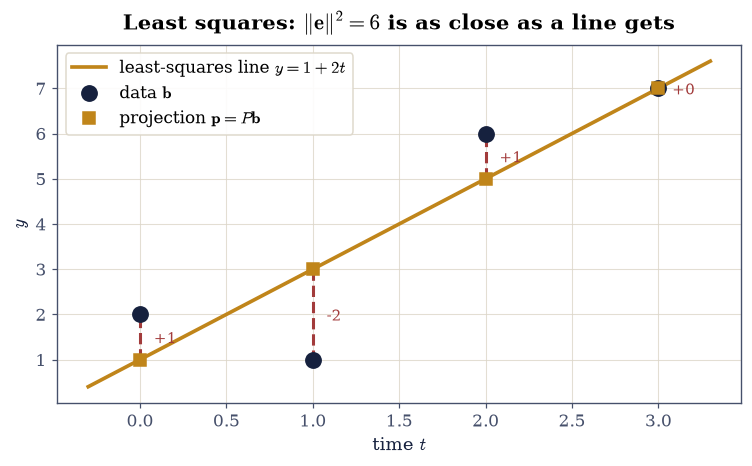

In [8]:
# (solution hidden on the public site)


### Validation 3

Every quantity here is an integer by construction, so the checks carry no
tolerance beyond what the solve introduces. The exact rational solution is
computed independently with SymPy, and the three floating-point routes —
normal equations, `lstsq`, and `polyfit` — must all agree with it.

In [9]:
validate.close(AtA, np.array([[4.0, 6.0], [6.0, 14.0]]),
               "A^T A is exactly [[4, 6], [6, 14]]", rtol=0.0, atol=0.0)
validate.close(Atb, np.array([16.0, 34.0]),
               "and A^T b is exactly (16, 34)", rtol=0.0, atol=0.0)
validate.close(x_normal, np.array([1.0, 2.0]),
               "the normal equations give x_hat = (1, 2)", rtol=0.0, atol=1e-13)
validate.check(
    list(x_exact) == [sp.Integer(1), sp.Integer(2)],
    "and the exact rational solution is (1, 2) with no rounding at all",
    "SymPy over the rationals, an independent route",
)
validate.close(x_lstsq, x_normal, "np.linalg.lstsq agrees", rtol=0.0, atol=1e-12)
validate.close(x_polyfit, x_normal, "and so does np.polyfit", rtol=0.0, atol=1e-12)
validate.close(p_fit, np.array([1.0, 3.0, 5.0, 7.0]),
               "the fitted values are exactly (1, 3, 5, 7)", rtol=0.0, atol=1e-13)
validate.close(e_fit, np.array([1.0, -2.0, 1.0, 0.0]),
               "and the residual is exactly (1, -2, 1, 0)", rtol=0.0, atol=1e-13)
validate.close(A_fit.T @ e_fit, np.zeros(2),
               "A^T e = 0: the residual is orthogonal to both columns (Eq. 2)",
               rtol=0.0, atol=1e-13)
validate.close(B_DATA @ B_DATA, p_fit @ p_fit + e_fit @ e_fit,
               "Pythagoras: 90 = 84 + 6 (Eq. 5)", rtol=0.0, atol=1e-12)

✓  A^T A is exactly [[4, 6], [6, 14]]   [max|Δ| = 0 (rtol=0, atol=0)]
✓  and A^T b is exactly (16, 34)   [max|Δ| = 0 (rtol=0, atol=0)]
✓  the normal equations give x_hat = (1, 2)   [max|Δ| = 0 (rtol=0, atol=1e-13)]
✓  and the exact rational solution is (1, 2) with no rounding at all   [SymPy over the rationals, an independent route]
✓  np.linalg.lstsq agrees   [max|Δ| = 0 (rtol=0, atol=1e-12)]
✓  and so does np.polyfit   [max|Δ| = 1.55431e-15 (rtol=0, atol=1e-12)]
✓  the fitted values are exactly (1, 3, 5, 7)   [max|Δ| = 0 (rtol=0, atol=1e-13)]
✓  and the residual is exactly (1, -2, 1, 0)   [max|Δ| = 0 (rtol=0, atol=1e-13)]
✓  A^T e = 0: the residual is orthogonal to both columns (Eq. 2)   [max|Δ| = 0 (rtol=0, atol=1e-13)]
✓  Pythagoras: 90 = 84 + 6 (Eq. 5)   [got 90 vs expected 90 (rtol=0, atol=1e-12)]


True

## Exercise 4: More columns: fitting a plane

Nothing in {eq}`eq-proj-normal` cared that $A$ had two columns. Adding a third
fits a plane $z = c + a x + b y$ instead of a line, and the machinery is
unchanged — which is the point. "Least squares" is not a family of formulas
per model; it is one projection, with the model living entirely in the columns
of $A$.

Take six sample points $(x_i, y_i)$ and measured heights $z_i$:

```{math}
:label: eq-proj-plane-data
\begin{array}{c|cccccc}
(x, y) & (0,0) & (1,0) & (0,1) & (1,1) & (2,1) & (1,2)\\ \hline
z & 1.0 & 2.5 & 2.5 & 4.3 & 4.8 & 5.9
\end{array}
\qquad
A = \begin{bmatrix} 1 & x_1 & y_1\\ \vdots & \vdots & \vdots\\ 1 & x_6 & y_6\end{bmatrix} .
```

Six equations, three unknowns. The design matrix has a column of ones for the
constant and one column per coordinate, and everything else proceeds exactly as
in Exercise 3.

The residual now has a clean interpretation worth naming. By
[§1.4](../01-matrices/four-subspaces.ipynb), $\mathbf{e}$ lies in
$N(A^{\top})$, which for this $A$ has dimension $6 - 3 = 3$. So the six
measurements decompose into three numbers a plane can represent and three it
cannot, and $\|\mathbf{e}\|$ measures the second group. A model with more
columns would leave a smaller residual — and fitting six columns to six points
would leave none at all, which is exactly the overfitting that
[§8.1](../08-learning/learning-as-least-squares.ipynb) confronts.

**Part a)** Build $A$ from {eq}`eq-proj-plane-data` with
`np.column_stack([np.ones(6), pts[:, 0], pts[:, 1]])`, solve the normal
equations with `np.linalg.solve(A.T @ A, A.T @ z)`, and report the fitted
plane. Cross-check against `np.linalg.lstsq(A, z, rcond=None)[0]` to
$10^{-11}$.

**Part b)** Confirm the geometry survives the extra column: check
$\operatorname{trace} P = 3 = \operatorname{rank} A$ to $10^{-11}$,
$A^{\top}\mathbf{e} = \mathbf{0}$ to $10^{-12}$ (now three orthogonality
conditions, one per column), and Pythagoras to $10^{-11}$.

**Part c)** Confirm the residual lies in the left null space: compute
$P_{N(A^{\top})} = I - P$ and check $\big(I - P\big)\mathbf{e} = \mathbf{e}$ to
$10^{-12}$ — the residual is already entirely in the unreachable subspace, so
projecting it there changes nothing. Report $\dim N(A^{\top}) = 3$ from
$\operatorname{trace}(I - P)$.

In [10]:
# (solution hidden on the public site)


A (6x3 design matrix):
 [[1. 0. 0.]
 [1. 1. 0.]
 [1. 0. 1.]
 [1. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]]

fitted plane: z = 1.068182 + 1.184091 x + 1.734091 y
np.linalg.lstsq agrees to 3.775e-15

trace P              : 3.0000000000   rank A = 3
A^T e                : [0. 0. 0.]
||z||^2 = 89.840000  =  ||p||^2 + ||e||^2 = 89.414773 + 0.425227

residual norm        : 0.652095
(I - P) e - e        : 2.054e-15
trace(I - P)         : 3.0000000000   = m - r = 3


### Validation 4

The check worth noticing is the last: $(I-P)\mathbf{e} = \mathbf{e}$ says the
residual is *already* entirely in the unreachable subspace, so projecting it
there is a no-op. That is a statement about where the residual lives, and it
ties this exercise directly back to
[§1.4](../01-matrices/four-subspaces.ipynb).

In [11]:
validate.close(x_plane, x_plane_lstsq,
               "the normal equations and np.linalg.lstsq agree on the plane fit",
               rtol=0.0, atol=1e-11)
validate.close(np.trace(P_plane), 3.0,
               "trace P = 3 = rank A: the projector's trace counts the columns",
               rtol=0.0, atol=1e-11)
validate.close(A_plane.T @ e_plane, np.zeros(3),
               "A^T e = 0: three orthogonality conditions, one per column",
               rtol=0.0, atol=1e-12)
validate.close(Z_DATA @ Z_DATA, p_plane @ p_plane + e_plane @ e_plane,
               "Pythagoras holds for the plane fit too", rtol=0.0, atol=1e-11)
validate.close(I_minus_P @ e_plane, e_plane,
               "(I - P) e = e: the residual already lies entirely in N(A^T)",
               rtol=0.0, atol=1e-12)
validate.close(np.trace(I_minus_P), 3.0,
               "and dim N(A^T) = m - r = 3, from trace(I - P)",
               rtol=0.0, atol=1e-11)
validate.check(
    np.linalg.norm(e_plane) > 1e-6,
    "the residual is genuinely nonzero: the data does not lie on a plane",
    f"||e|| = {np.linalg.norm(e_plane):.4f}, which is what the model cannot explain",
)

✓  the normal equations and np.linalg.lstsq agree on the plane fit   [max|Δ| = 3.77476e-15 (rtol=0, atol=1e-11)]
✓  trace P = 3 = rank A: the projector's trace counts the columns   [got 3 vs expected 3 (rtol=0, atol=1e-11)]
✓  A^T e = 0: three orthogonality conditions, one per column   [max|Δ| = 6.21725e-15 (rtol=0, atol=1e-12)]
✓  Pythagoras holds for the plane fit too   [got 89.84 vs expected 89.84 (rtol=0, atol=1e-11)]
✓  (I - P) e = e: the residual already lies entirely in N(A^T)   [max|Δ| = 2.05391e-15 (rtol=0, atol=1e-12)]
✓  and dim N(A^T) = m - r = 3, from trace(I - P)   [got 3 vs expected 3 (rtol=0, atol=1e-11)]
✓  the residual is genuinely nonzero: the data does not lie on a plane   [||e|| = 0.6521, which is what the model cannot explain]


True

## Exercise 5: The complementary projector, and the two halves of the data

{eq}`eq-proj-properties` noted that $I - P$ is also a projector. It is worth
making that explicit, because the pair $(P,\ I-P)$ *is* the decomposition
[§1.4](../01-matrices/four-subspaces.ipynb) drew, now available as two
matrices you can apply.

For any $\mathbf{b}$,

```{math}
:label: eq-proj-splitting
\mathbf{b} = \underbrace{P\mathbf{b}}_{\in\, C(A)}
           + \underbrace{(I - P)\mathbf{b}}_{\in\, N(A^{\top})} ,
\qquad P + (I - P) = I ,
```

and the two pieces are orthogonal. The first is the part of the data the model
can produce; the second is the part it cannot. Least squares keeps the first
and reports the size of the second.

There is one degenerate case worth checking, because it is the sanity boundary
of the whole construction: if $A$ is square and invertible, its column space is
all of $\mathbb{R}^m$, nothing is unreachable, and $P$ must be the identity
with $I - P = 0$. Least squares then reduces to solving the system exactly,
which is what it should do.

**Part a)** For the $4\times2$ design matrix {eq}`eq-proj-design`, build both
$P$ and $I - P$, and confirm: both are idempotent and symmetric to $10^{-13}$;
$P + (I-P) = I$ exactly; and $P(I-P) = 0$ to $10^{-13}$, so the two ranges are
orthogonal.

**Part b)** Confirm the trace split: $\operatorname{trace} P = 2$ and
$\operatorname{trace}(I-P) = 2$, summing to $m = 4$, matching the dimensions
$r$ and $m - r$ of [§1.4](../01-matrices/four-subspaces.ipynb).

**Part c)** Confirm the degenerate case: for the invertible
$A_{\text{sq}} = \begin{psmallmatrix}2&1\\1&3\end{psmallmatrix}$, build $P$ and
check it equals $I_2$ to $10^{-13}$, that $I - P = 0$, and that the
least-squares solution from `np.linalg.lstsq` equals `np.linalg.solve` to
$10^{-13}$ for the right-hand side $\mathbf{b} = (5, 10)^{\top}$.

```{admonition} With your assistant
:class: tip
Ask for a function `oblique_projector(A, W)` producing the *oblique* projector
$P_W = A(A^{\top}WA)^{-1}A^{\top}W$ for a symmetric positive definite weight
$W$ — the projector behind **weighted** least squares, which
[§2.3](least-squares-four-ways.ipynb) uses when measurements have unequal
uncertainties. Then check it yourself: it must satisfy $P_W^2 = P_W$ to
$10^{-12}$ for 20 random $W$, it must **fail** $P_W^{\top} = P_W$ whenever
$W \neq I$ (that is what "oblique" means), and it must reduce exactly to the
$P$ of this notebook when $W = I$. The check is yours.
```

In [12]:
# (solution hidden on the public site)


P^2 - P          : 2.220e-16
(I-P)^2 - (I-P)  : 1.665e-16
(I-P)^T - (I-P)  : 5.551e-17
P + (I-P) - I    : 0.000e+00
P (I-P)          : 1.743e-16   (the ranges are orthogonal)

trace P          : 2.0000000000   (= r)
trace (I-P)      : 2.0000000000   (= m - r)
sum              : 4.0000000000   (= m = 4)

square invertible A (det = 5.0):
  P - I                 : 2.220e-16
  I - P                 : 2.220e-16
  lstsq vs solve        : 1.332e-15


### Validation 5

The degenerate case is the one that matters most as a check: if the
construction did *not* reduce to an ordinary solve when nothing is unreachable,
something would be wrong with the derivation rather than with the arithmetic.

In [13]:
validate.close(Q2 @ Q2, Q2, "I - P is idempotent, so it is also a projector",
               rtol=0.0, atol=1e-13)
validate.close(Q2.T, Q2, "and symmetric, so it is an ORTHOGONAL projector",
               rtol=0.0, atol=1e-13)
validate.close(np.trace(P2), 2.0,
               "trace P = 2 = r, the dimension of the plane it projects onto",
               rtol=0.0, atol=1e-12)
validate.close(P2 @ Q2, np.zeros((4, 4)),
               "P (I - P) = 0: their ranges are orthogonal subspaces",
               rtol=0.0, atol=1e-13)
validate.close(np.trace(Q2), 2.0,
               "and trace (I - P) = 2 = m - r, matching the split of section 1.4",
               rtol=0.0, atol=1e-12)
validate.close(P_sq, np.eye(2),
               "for a square invertible A the projector is the identity",
               rtol=0.0, atol=1e-13)
validate.close(
    np.linalg.lstsq(A_sq, b_sq, rcond=None)[0], np.linalg.solve(A_sq, b_sq),
    "so least squares reduces to an ordinary solve, as it must",
    rtol=0.0, atol=1e-13,
)

✓  I - P is idempotent, so it is also a projector   [max|Δ| = 1.66533e-16 (rtol=0, atol=1e-13)]
✓  and symmetric, so it is an ORTHOGONAL projector   [max|Δ| = 5.55112e-17 (rtol=0, atol=1e-13)]
✓  trace P = 2 = r, the dimension of the plane it projects onto   [got 2 vs expected 2 (rtol=0, atol=1e-12)]
✓  P (I - P) = 0: their ranges are orthogonal subspaces   [max|Δ| = 1.74305e-16 (rtol=0, atol=1e-13)]
✓  and trace (I - P) = 2 = m - r, matching the split of section 1.4   [got 2 vs expected 2 (rtol=0, atol=1e-12)]
✓  for a square invertible A the projector is the identity   [max|Δ| = 2.22045e-16 (rtol=0, atol=1e-13)]
✓  so least squares reduces to an ordinary solve, as it must   [max|Δ| = 1.33227e-15 (rtol=0, atol=1e-13)]


True

## Notebook summary

When $\mathbf{b}$ is out of reach, the answer is a perpendicular.

The concrete results:

- the projector onto the line through $(2,1)^{\top}$ came out
  $\tfrac15\begin{psmallmatrix}4&2\\2&1\end{psmallmatrix}$ by two independent
  constructions, with $P^2 = P$, $P^{\top} = P$, and
  $\operatorname{trace} P = \operatorname{rank} P = 1$;
- for the $4\times2$ design matrix, $P$ satisfied $PA = A$ and annihilated the
  left null space, and was **unchanged under 50 random changes of basis** to
  $10^{-11}$ — it is an invariant of the subspace, not of the parametrisation;
- the four measurements $\mathbf{b} = (2,1,6,7)$ at $t = 0,1,2,3$ gave
  $A^{\top}A = \begin{psmallmatrix}4&6\\6&14\end{psmallmatrix}$ and
  $A^{\top}\mathbf{b} = (16,34)$ exactly, best-fit line $y = 1 + 2t$ with
  $\hat{\mathbf{x}} = (1,2)$ confirmed by the normal equations, `lstsq`,
  `polyfit` **and** exact rational arithmetic; the projection was $(1,3,5,7)$,
  the residual exactly $(1,-2,1,0)$ orthogonal to both columns, and
  $\|\mathbf{b}\|^2 = 90 = 84 + 6$;
- the same machinery fitted a plane to six points with no change beyond an
  extra column, giving three orthogonality conditions instead of two, and the
  residual satisfied $(I-P)\mathbf{e} = \mathbf{e}$ — it lies entirely in the
  three-dimensional $N(A^{\top})$, the part of the data no plane can produce;
- and $I - P$ was confirmed to be the complementary orthogonal projector with
  $P(I-P) = 0$ and traces summing to $m$, degenerating correctly to
  $P = I$, $I - P = 0$ when $A$ is square and invertible, where least squares
  becomes an ordinary solve.

Methods met: `np.outer` for a rank-one projector, $P = A(A^{\top}A)^{-1}A^{\top}$
built by **solving** rather than inverting, the normal equations
{eq}`eq-proj-normal`, `np.linalg.lstsq`, `np.polyfit`, and the trace of a
projector as the dimension of its range.

## Outlook

- **The arithmetic, which is not yet right.** Everything here formed
  $A^{\top}A$. That squares the condition number, so a fit that is mildly
  awkward becomes numerically hopeless.
  [§2.3](least-squares-four-ways.ipynb) measures the damage on Vandermonde
  matrices and finds four orders of magnitude by degree 14.
- **The repair.** If the columns of $A$ were **orthonormal**, then
  $A^{\top}A = I$ and the projector would be just $QQ^{\top}$, with no inverse
  to form and no conditioning penalty. Manufacturing such a basis is the $QR$
  factorization of [§2.2](gram-schmidt-qr.ipynb), and it is the correct way to
  solve least squares.
- **When the columns are not independent.** $A^{\top}A$ is then singular and
  {eq}`eq-proj-projector` fails, though the *projection* still exists — the
  geometry never needed independence, only the formula did.
  [§2.4](pseudoinverse-regularization.ipynb) handles that case with the
  pseudoinverse.
- **Weighting the measurements.** All four residuals counted equally here. If
  some measurements are more trustworthy, the right object is a weighted
  projector, which is oblique rather than orthogonal — the assistant callout
  above builds one, and [§2.3](least-squares-four-ways.ipynb) uses it.

### References

```{bibliography}
:filter: docname in docnames
```

In [14]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>